<a href="https://colab.research.google.com/github/ktw2128/advanced_quant_2026/blob/main/advanced_quant_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ENSO is known to be a source of predictability for seasonal North Atlantic tropical cyclone activity. Please download the North Atlantic tropical cyclone counts labeled by ENSO state from the coursework: hurricane_counts_by_enso.csv and answer the questions 8-10 (30%).  

8. Now let’s examining whether there is a clear shift in the mean and variance of North Atlantic TC counts during El Niño and La Niña events, using a t-test with a significance level of α = 0.05, please describe your findings. (10%)
H0 (t-test): TC counts have the same mean between El Niño and La Niña.

9. Now using a F-test with a significance level of α = 0.05, please describe your findings (10%)
H0 (F-test): TC counts have the same variance between El Niño and La Niña.

10. Let’s conduct Kruskal-Wallis test on are Atlantic TC counts conditioned on ENSO phase? Describe your findings (10%)
H0: TC counts have the same distribution across El Niño, Neutral, and La Niña. H1: At least one group's distribution differs.


In [18]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt

# Paste your copied path inside the quotes
df = pd.read_csv('/content/drive/MyDrive/Fall 2026/Advanced Quantitative Methods for Climate/hurricane_counts_by_enso.csv')

# View the first few rows
df.head()


,year,hurricane_count,roni_aso,enso_phase
0,1951,12,1.04,El Nino
1,1952,11,0.08,Neutral
2,1953,14,0.65,El Nino
3,1954,16,-0.54,La Nina
4,1955,13,-0.90,La Nina


In [22]:
el_nino_hurricanes = df[df['enso_phase'] == 'El Nino']['hurricane_count']
la_nina_hurricanes = df[df['enso_phase'] == 'La Nina']['hurricane_count']
neutral_hurricanes = df[df['enso_phase'] == 'Neutral']['hurricane_count']

In [10]:
# Calculate mean and variance for El Niño
print("El Niño Mean:", el_nino_hurricanes.mean())
print("El Niño Variance:", el_nino_hurricanes.var())

# Calculate mean and variance for La Niña
print("La Niña Mean:", la_nina_hurricanes.mean())
print("La Niña Variance:", la_nina_hurricanes.var())


El Niño Mean: 10.19047619047619
El Niño Variance: 15.06190476190476
La Niña Mean: 15.142857142857142
La Niña Variance: 28.728571428571435


In [15]:
#t-statistic
t_stat, p_val = stats.ttest_ind(el_nino_hurricanes, la_nina_hurricanes, equal_var=False)
print("T-statistic:", t_stat)
print("P-value:", p_val)


T-statistic: -3.4295240914291463
P-value: 0.0015169155204574466


In [16]:
# F-statistic
n1, n2 = len(el_nino_hurricanes), len(la_nina_hurricanes)
sigma1, sigma2 = el_nino_hurricanes.var(ddof=1), la_nina_hurricanes.var(ddof=1)
F = sigma1**2 / sigma2**2       # convention: larger-variance group in numerator is optional;
dfn, dfd = n1 - 1, n2 - 1      # here it's just recent/early as defined
print(f"F = {F:.4f}, df=({dfn},{dfd})")

F = 0.2749, df=(20,20)


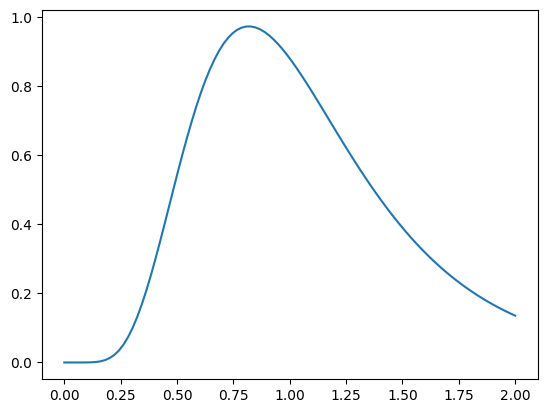

In [19]:
xs = np.linspace(0, 2, 100)
ys = stats.f.pdf(xs, dfn, dfd)
plt.plot(xs, ys)

In [20]:
p_lower = stats.f.cdf(F, dfn, dfd)
p_upper = 1 - stats.f.cdf(F, dfn, dfd)
p_val = 2 * min(p_upper, p_lower)

print(f" p = {p_val:.4g}")

 p = 0.005739


 Let’s conduct Kruskal-Wallis test on are Atlantic TC counts conditioned on ENSO phase? Describe your findings (10%)
H0: TC counts have the same distribution across El Niño, Neutral, and La Niña. H1: At least one group's distribution differs.


In [24]:
# Kruskal-Wallis test
h_stat, p_value = stats.kruskal(el_nino_hurricanes, neutral_hurricanes, la_nina_hurricanes)

print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_value:.4e}")

H-statistic: 14.3211
p-value: 7.7662e-04
